# Dünya Mutluluk Raporu (WHR) 2024: Mutluluk Skorlarını Etkileyen Faktörlerin Analizi, Tahmini ve Kümeleme Çalışması

### Kütüphanelerin yüklenmesi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from xgboost import XGBRegressor
from xgboost import plot_importance

from scipy.stats import pearsonr


from statsmodels.nonparametric.smoothers_lowess import lowess


### Data Understanding

In [2]:
df = pd.read_csv('/Users/nisasahinoglu/Downloads/WHR25_Data.csv', sep = ';')

Veri Seti Sütunları ve Açıklamaları

1. **Year**  
   - Veri kaydının ait olduğu yıl.

2. **Rank**  
   - Ülkenin mutluluk veya yaşam tatmini sıralaması.

3. **Country_name**  
   - Ülke adı.

4. **Life_evaluation_3_year_average**  
   - 3 yıllık ortalama yaşam değerlendirmesi/skoru (Life Evaluation).

5. **Lower_whisker**  
   - Yaşam değerlendirmesi için alt sınır (istatistiksel olarak whisker değeri).

6. **Upper_whisker**  
   - Yaşam değerlendirmesi için üst sınır (istatistiksel olarak whisker değeri).

7. **Log_GDP_per_capita**  
   - Kişi başına düşen GSYİH’nin logaritması (gelir göstergesi).

8. **Social_support**  
   - Sosyal destek düzeyi (bireylerin yardım ve destek alabilme durumu).

9. **Healthy_life_expectancy**  
   - Sağlıklı yaşam beklentisi (ortalama kaç yıl sağlıklı yaşanabileceği).

10. **Freedom_to_make_life_choices**  
    - Hayat seçimlerinde özgürlük algısı.

11. **Generosity**  
    - Cömertlik düzeyi (bağış ve yardım davranışları).

12. **Perceptions_of_corruption**  
    - Yolsuzluk algısı (toplumdaki yolsuzluk seviyesinin algılanması).

13. **Dystopia_and_residual**  
    - Dystopia (ideal olmayan ülke) referans skoru ve diğer kalıntılar (modelleme için kullanılan varsayımsal değer).


In [3]:
df.head()

,Year,Rank,Country_name,Life_evaluation_3_year_average,Lower_whisker,Upper_whisker,Log_GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Dystopia_and_residual
0,2024,147,Afghanistan,"1,364","1,301","1,427","0,649","0,000","0,155","0,000","0,075","0,135","0,348"
1,2023,143,Afghanistan,"1,721","1,667","1,775","0,628","0,000","0,242","0,000","0,091","0,088","0,672"
2,2022,137,Afghanistan,"1,859","1,795","1,923","0,645","0,000","0,087","0,000","0,093","0,059","0,976"
3,2021,146,Afghanistan,"2,404","2,339","2,469","0,758","0,000","0,289","0,000","0,089","0,005","1,263"
4,2020,150,Afghanistan,"2,523","2,449","2,596","0,370","0,000","0,126","0,000","0,122","0,010","1,895"


In [4]:
df.columns

Index(['Year', 'Rank', 'Country_name', 'Life_evaluation_3_year_average',
       'Lower_whisker', 'Upper_whisker', 'Log_GDP_per_capita',
       'Social_support', 'Healthy_life_expectancy',
       'Freedom_to_make_life_choices', 'Generosity',
       'Perceptions_of_corruption', 'Dystopia_and_residual'],
      dtype='object')

In [5]:
df.Year.unique()

array([2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014,
       2012, 2011])

In [6]:
df = df[df['Year']==2024].copy() # analiz sadece 2024 yılını kapsayacak

In [7]:
df.Year.unique()

array([2024])

In [8]:
df.isnull().sum()

Year                              0
Rank                              0
Country_name                      0
Life_evaluation_3_year_average    0
Lower_whisker                     0
Upper_whisker                     0
Log_GDP_per_capita                0
Social_support                    0
Healthy_life_expectancy           1
Freedom_to_make_life_choices      1
Generosity                        0
Perceptions_of_corruption         1
Dystopia_and_residual             3
dtype: int64

In [9]:
df[df.isnull().any(axis = 1)] 

,Year,Rank,Country_name,Life_evaluation_3_year_average,Lower_whisker,Upper_whisker,Log_GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Dystopia_and_residual
1335,2024,52,Oman,"6,197","5,973","6,420","1,603","1,411","0,500","0,930","0,142",NaN,NaN
1644,2024,108,State of Palestine,"4,780","4,675","4,886","1,047","1,456",NaN,"0,618","0,055","0,081",NaN
1717,2024,90,Tajikistan,"5,411","5,337","5,485","0,914","1,555","0,658",NaN,"0,085","0,342",NaN


In [10]:
df = df.dropna() # 3 adet null sütunu olan kayıt olduğu için eksik değerleri sildik

In [11]:
df.isnull().sum()

Year                              0
Rank                              0
Country_name                      0
Life_evaluation_3_year_average    0
Lower_whisker                     0
Upper_whisker                     0
Log_GDP_per_capita                0
Social_support                    0
Healthy_life_expectancy           0
Freedom_to_make_life_choices      0
Generosity                        0
Perceptions_of_corruption         0
Dystopia_and_residual             0
dtype: int64

In [12]:
numeric_cols = [
    'Life_evaluation_3_year_average', 'Lower_whisker', 
    'Upper_whisker', 'Log_GDP_per_capita', 
    'Social_support', 'Healthy_life_expectancy', 
    'Freedom_to_make_life_choices', 'Generosity', 'Perceptions_of_corruption', 'Dystopia_and_residual'
]

# 3. HATA ÇÖZÜMÜ: Numerik değerler virgülle ayrılmıştı pandasın sayı olarak algılaması için . yapıyoruz
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,144.0,2024.000000,0.000000,2024.000,2024.00000,2024.0000,2024.00000,2024.000
Rank,144.0,73.805556,42.868848,1.000,36.75000,73.5000,111.25000,147.000
Life_evaluation_3_year_average,144.0,5.580576,1.167227,1.364,4.66550,5.8690,6.49250,7.736
Lower_whisker,144.0,5.470514,1.178224,1.301,4.55100,5.7525,6.38725,7.662
Upper_whisker,144.0,5.690611,1.157185,1.427,4.77950,5.9710,6.59950,7.810
Log_GDP_per_capita,144.0,1.321424,0.395155,0.000,1.03750,1.3590,1.65400,2.028
Social_support,144.0,1.330465,0.352897,0.000,1.12875,1.4340,1.59625,1.840
Healthy_life_expectancy,144.0,0.551111,0.220104,0.000,0.41325,0.5505,0.71475,0.948
Freedom_to_make_life_choices,144.0,0.748910,0.177954,0.000,0.65900,0.7670,0.87975,1.018
Generosity,144.0,0.113847,0.060103,0.000,0.06675,0.1110,0.15150,0.323


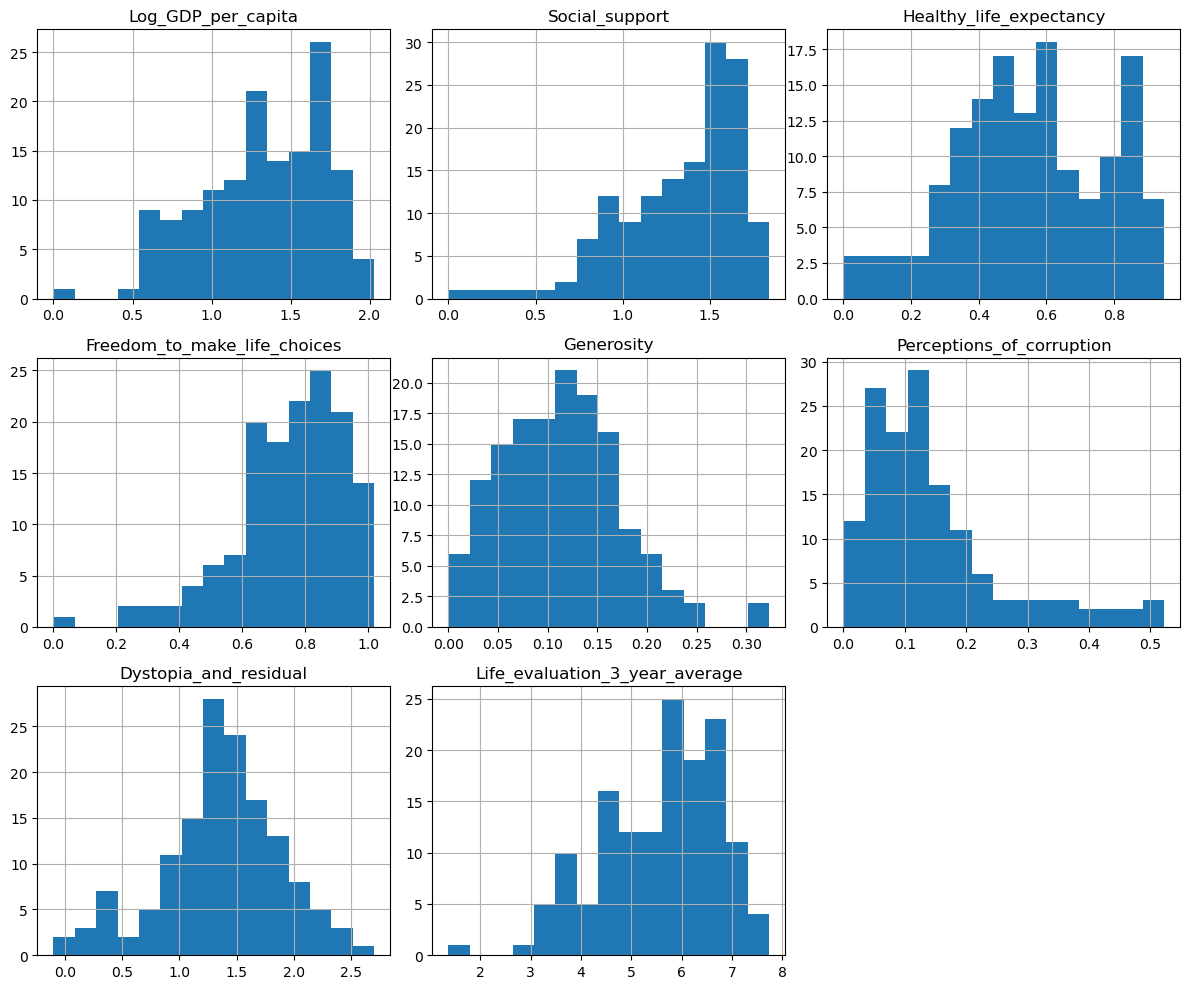

In [14]:
features = [
    "Log_GDP_per_capita",
    "Social_support",
    "Healthy_life_expectancy",
    "Freedom_to_make_life_choices",
    "Generosity",
    "Perceptions_of_corruption",
    "Dystopia_and_residual",
    "Life_evaluation_3_year_average"
]

df[features].hist(bins=15, figsize=(12,10))
plt.tight_layout()
plt.show()


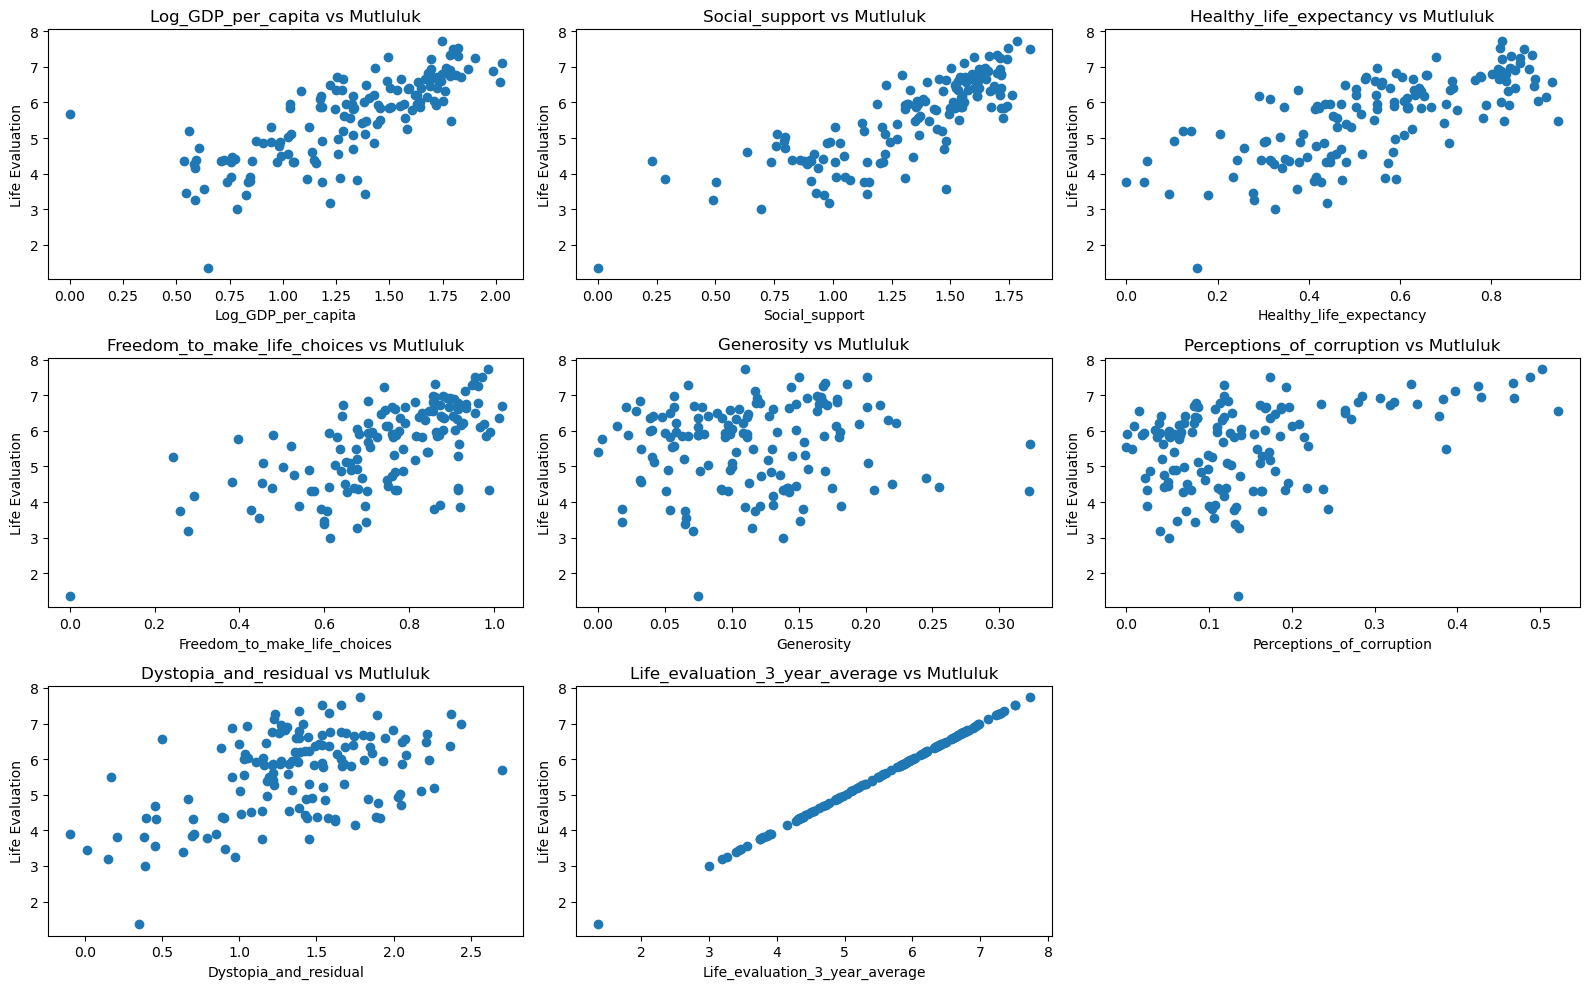

In [15]:


plt.figure(figsize=(16,10))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    plt.scatter(df[feature], df["Life_evaluation_3_year_average"])
    plt.xlabel(feature)
    plt.ylabel("Life Evaluation")
    plt.title(f"{feature} vs Mutluluk")

plt.tight_layout()
plt.show()


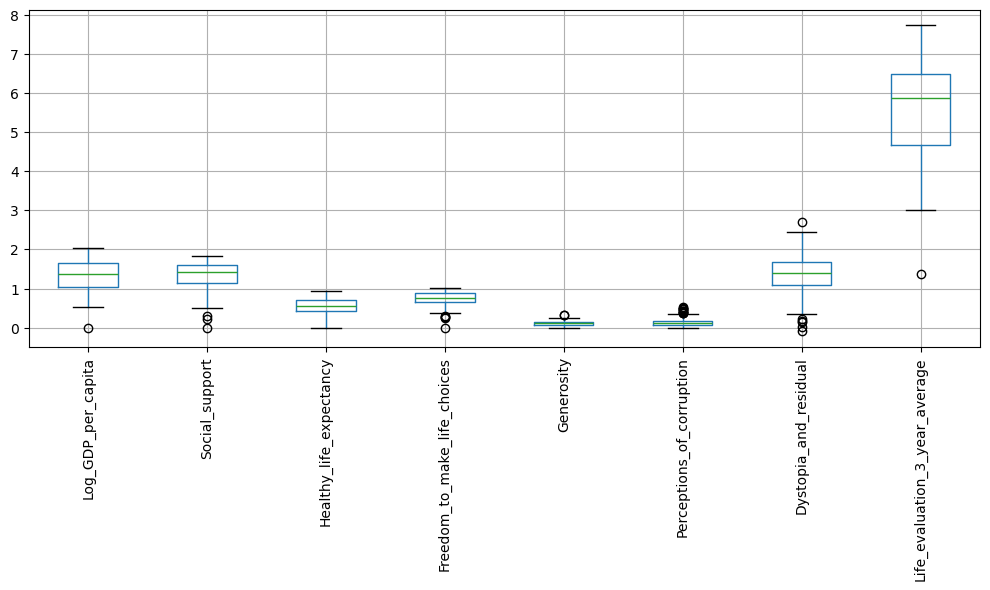

In [16]:
plt.figure(figsize=(10,6))
df[features].boxplot(rot=90)
plt.tight_layout()
plt.show()


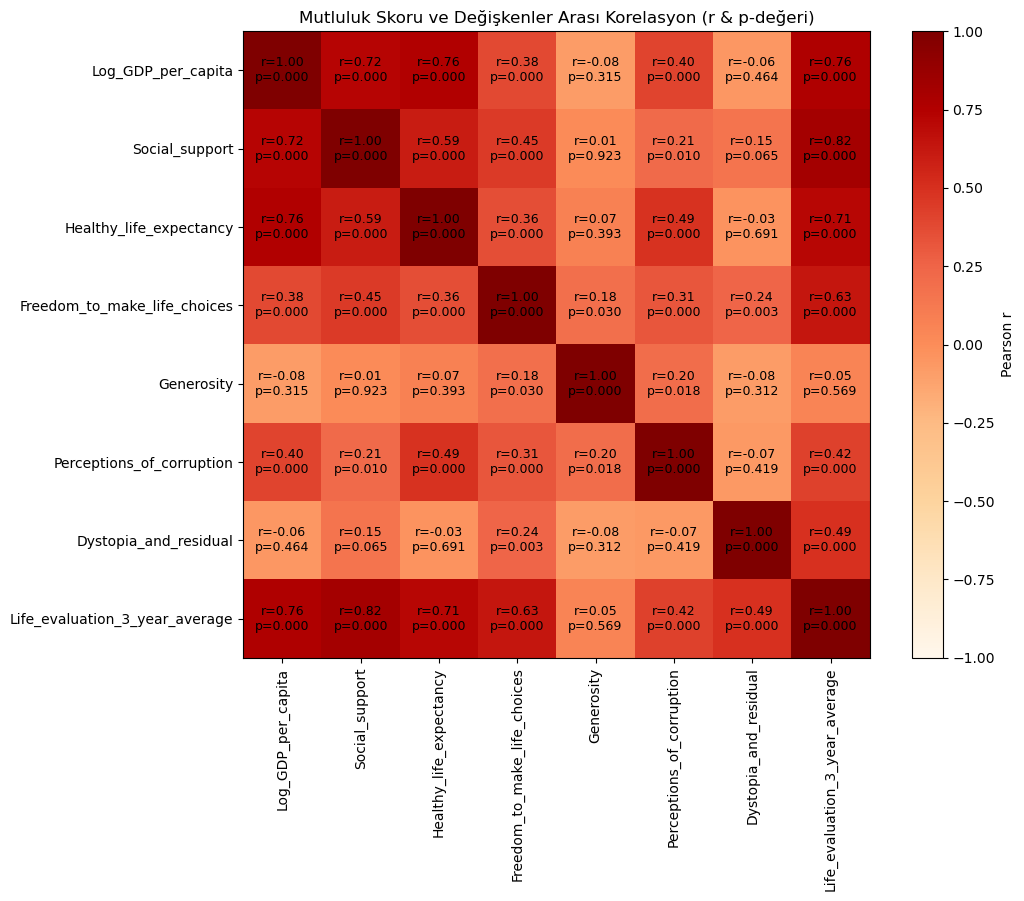

In [ ]:


corr_matrix = df[features].corr()

# p-value matrisi
p_matrix = np.zeros((len(features), len(features)))

for i in range(len(features)):
    for j in range(len(features)):
        r, p = pearsonr(df[features[i]], df[features[j]])
        p_matrix[i, j] = p



plt.figure(figsize=(11,9))


plt.imshow(corr_matrix, cmap="OrRd", vmin=-1, vmax=1)
plt.colorbar(label="Pearson r")

plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)


for i in range(len(features)):
    for j in range(len(features)):
        r = corr_matrix.iloc[i, j]
        p = p_matrix[i, j]
        plt.text(
            j, i,
            f"r={r:.2f}\np={p:.3f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Mutluluk Skoru ve Değişkenler Arası Korelasyon (r & p-değeri)")
plt.tight_layout()
plt.show()
plt.show()


-> Life_evaluation_3_year_average ve Generosity arasındaki ilişki p > 0.05 olduğu için anlamsızdır.


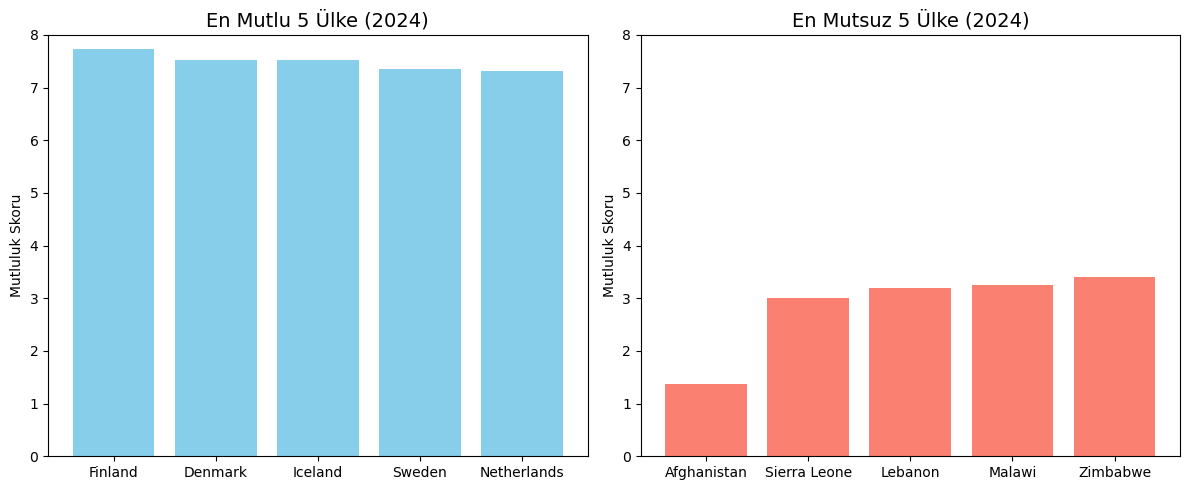

In [18]:
# En yüksek ve en düşük 5 ülke
top_5 = df.nsmallest(5, 'Rank') # Rank 1 en mutludur
bottom_5 = df.nlargest(5, 'Rank') # Rank en büyük olan en mutsuzdur


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# En Mutlu 5 Ülke
axes[0].bar(top_5['Country_name'], top_5['Life_evaluation_3_year_average'], color='skyblue')
axes[0].set_title('En Mutlu 5 Ülke (2024)', fontsize=14)
axes[0].set_ylabel('Mutluluk Skoru')
axes[0].set_ylim(0, 8)


# En Mutsuz 5 Ülke
axes[1].bar(bottom_5['Country_name'], bottom_5['Life_evaluation_3_year_average'], color='salmon')
axes[1].set_title('En Mutsuz 5 Ülke (2024)', fontsize=14,)
axes[1].set_ylabel('Mutluluk Skoru')
axes[1].set_ylim(0, 8)

plt.tight_layout()
plt.show()

In [19]:
# Generosity istatiksel olarak anlamlı olmadığı için yok
# Özelliklerin önemini analiz etmek amacıyla ağaç tabanlı makine öğrenmesi algoritmalarını
# eğiterek özelliklerin önem derecesini bulmaya çalışıyoruz

features = [
    "Log_GDP_per_capita",
    "Social_support",
    "Healthy_life_expectancy",
    "Freedom_to_make_life_choices",
    "Perceptions_of_corruption",
    "Dystopia_and_residual",
]
X = df[features]
y = df["Life_evaluation_3_year_average"]

In [20]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [21]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }


In [22]:
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = evaluate_model(model, X_test, y_test)

results_df = pd.DataFrame(results).T
print(results_df)


                    MSE      RMSE       MAE      MAPE        R2
Decision Tree  0.339472  0.582642  0.435241  0.096906  0.775753
Random Forest  0.131334  0.362401  0.300757  0.062888  0.913244
XGBoost        0.378861  0.615517  0.425480  0.094219  0.749733


Modeller üzerinde hiperparametre ayarları yaparak modellerin en iyi performanslarını vermesi sağlanır

In [23]:
dt_params = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_


rf_params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

xgb_params = {
    "n_estimators": [200, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 8],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    xgb_params,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_


In [24]:
tuned_models = {
    "Decision Tree (Tuned)": best_dt,
    "Random Forest (Tuned)": best_rf,
    "XGBoost (Tuned)": best_xgb
}

tuned_results = {}

for name, model in tuned_models.items():
    tuned_results[name] = evaluate_model(model, X_test, y_test)

tuned_results_df = pd.DataFrame(tuned_results).T
print(tuned_results_df)


                            MSE      RMSE       MAE      MAPE        R2
Decision Tree (Tuned)  0.296902  0.544887  0.398500  0.088985  0.803874
Random Forest (Tuned)  0.131334  0.362401  0.300757  0.062888  0.913244
XGBoost (Tuned)        0.051163  0.226192  0.160661  0.032885  0.966203


#### XGBoost algoritması en yüksek R2 ve en düşük hataya sahip olduğu için en iyi algoritma olarak seçildi

<Figure size 1000x700 with 0 Axes>

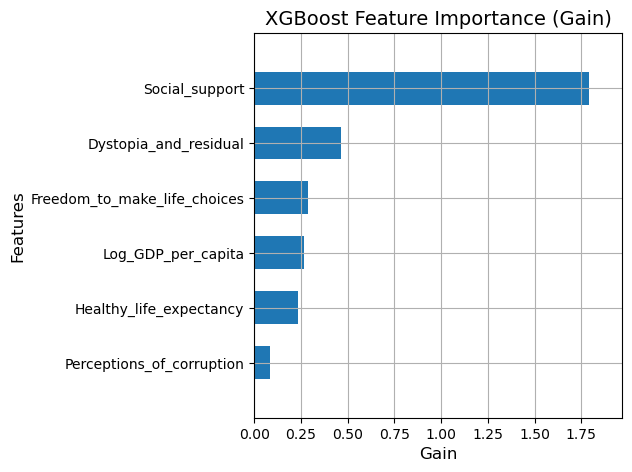

In [25]:


plt.figure(figsize=(10, 7)) 
plot_importance(
    best_xgb,
    importance_type="gain",
    max_num_features=10,
    height=0.6,              
    show_values=False        
)

plt.title("XGBoost Feature Importance (Gain)", fontsize=14)
plt.xlabel("Gain", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout(pad=1.0)   
plt.show()


#### XGBoost algoritmasının açık ara en çok önemsediği özellik social_sport oldu. Şimdi bu özelliğin mutluluk üzerindeki etkisini daha detaylı inceleyeceğiz

In [26]:
# 2 özelliğe dayanarak kümeleme yapacağız

features_cluster = [
    "Social_support",
    "Life_evaluation_3_year_average"
]


In [27]:
X = df[features_cluster]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


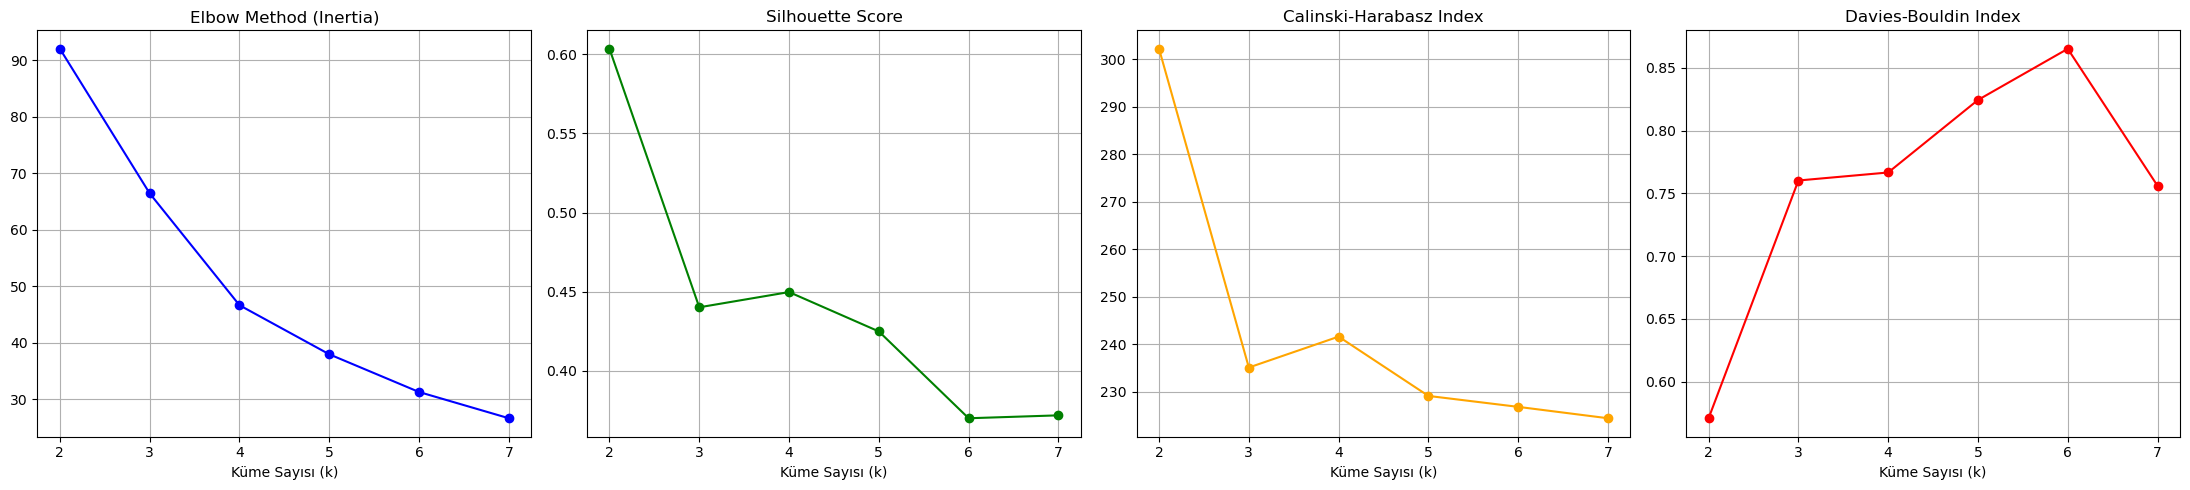

In [28]:

# Küme sayısı aralığını belirlemek amacı ile en popüler 3 yöntemi kullanıyoruz

# Değerleri hesaplamak için boş listeler
k_range = range(2, 8)
inertias, sil_scores, ch_scores, db_scores = [], [], [], []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# Yan yana 4 grafik oluşturma
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 1️⃣ Elbow Method
axes[0].plot(k_range, inertias, marker='o', color='b')
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("Küme Sayısı (k)")

# 2️⃣ Silhouette Score (Daha yüksek daha iyi)
axes[1].plot(k_range, sil_scores, marker='o', color='g')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Küme Sayısı (k)")

# 3️⃣ Calinski-Harabasz Index (Daha yüksek daha iyi)
axes[2].plot(k_range, ch_scores, marker='o', color='orange')
axes[2].set_title("Calinski-Harabasz Index")
axes[2].set_xlabel("Küme Sayısı (k)")

# 4️⃣ Davies-Bouldin Index (Daha düşük daha iyi)
axes[3].plot(k_range, db_scores, marker='o', color='r')
axes[3].set_title("Davies-Bouldin Index")
axes[3].set_xlabel("Küme Sayısı (k)")

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

In [29]:
# Elbow metodunda 4, Silhouette ve Calinski-Harabasz' da 3 veya 4, Davies-Bouldin 3 veya 4 olabileceği için 4 küme seçildi

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["SocialSupport_Cluster"] = kmeans.fit_predict(X_scaled)


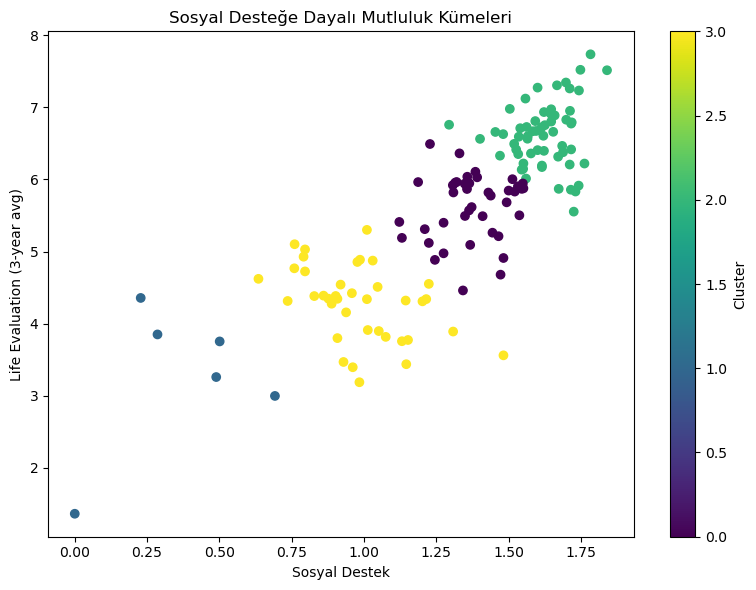

In [30]:


plt.figure(figsize=(8, 6))
plt.scatter(
    df["Social_support"],
    df["Life_evaluation_3_year_average"],
    c=df["SocialSupport_Cluster"],
    cmap="viridis"
)

plt.xlabel("Sosyal Destek")
plt.ylabel("Life Evaluation (3-year avg)")
plt.title("Sosyal Desteğe Dayalı Mutluluk Kümeleri")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()


In [31]:
cluster_summary = (
    df.groupby("SocialSupport_Cluster")[features_cluster]
    .mean()
)

print(cluster_summary.T)


SocialSupport_Cluster                  0      1         2         3
Social_support                  1.374488  0.366  1.622051  0.982526
Life_evaluation_3_year_average  5.623341  3.264  6.619153  4.287684


In [40]:
cluster_profiles = (
    df.groupby("SocialSupport_Cluster")
      .agg({
          "Country_name": "count",
          "Social_support": "mean",
          "Life_evaluation_3_year_average": "mean"
      })
      .rename(columns={"Country_name": "Number_of_Countries"})
)

cluster_profiles


,Number_of_Countries,Social_support,Life_evaluation_3_year_average
SocialSupport_Cluster,,,
0,41,1.374488,5.623341
1,6,0.366000,3.264000
2,59,1.622051,6.619153
3,38,0.982526,4.287684


| Küme (Cluster) | Sosyal Destek | Yaşam Değerlendirmesi | Analiz |
| :--- | :---: | :---: | :--- |
| **Cluster 2** | 1.622 | 6.619 | **Zirve Grup:** Hem sosyal desteğin hem de mutluluk skorunun en yüksek olduğu küme. |
| **Cluster 0** | 1.374 | 5.623 | **Üst-Orta:** Güçlü bir sosyal destek yapısına sahip, yaşam memnuniyeti yüksek ülkeler/gruplar. |
| **Cluster 3** | 0.982 | 4.287 | **Alt-Orta:** Sosyal desteğin 1.0 seviyesinin altına düşmesiyle yaşam kalitesinde belirgin bir düşüş gözleniyor. |
| **Cluster 1** | 0.366 | 3.264 | **Riskli Grup:** Sosyal desteğin en zayıf olduğu, buna paralel olarak en düşük yaşam değerlendirmesine sahip küme. |

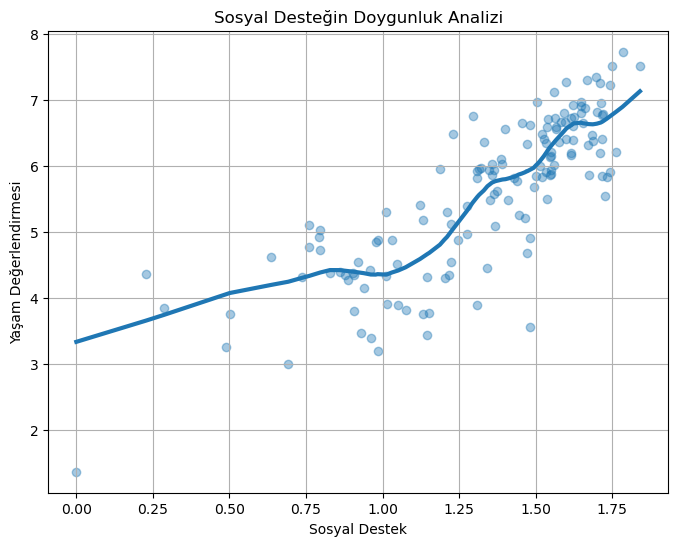

In [41]:



x = df["Social_support"]
y = df["Life_evaluation_3_year_average"]

lowess_curve = lowess(y, x, frac=0.3)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.4)
plt.plot(lowess_curve[:, 0], lowess_curve[:, 1], linewidth=3)
plt.xlabel("Sosyal Destek")
plt.ylabel("Yaşam Değerlendirmesi")
plt.title("Sosyal Desteğin Doygunluk Analizi")
plt.grid(True)
plt.show()


Grafik Analizi ve Yorumlar

Pozitif Korelasyon: Sosyal destek arttıkça yaşam değerlendirmesinin (mutluluğun) arttığı çok net görülüyor. 

Hızlanma Noktası (Eşik Değeri): Grafikte, Sosyal Destek 1.25 seviyesini geçtikten sonra eğri daha dik bir ivme kazanıyor. Bu, belirli bir sosyal destek seviyesinden sonra mutluluk skorunun çok daha hızlı yükseldiğini gösteriyor.

Doygunluk Durumu: Eğrinin en sağ ucuna (1.75 ve sonrası) baktığımızda, yükselişin devam ettiğini ancak biraz daha dalgalı bir hal aldığını görüyoruz. Tam bir "yatay doygunluk" henüz oluşmamış; yani sosyal destek arttıkça mutluluk hala artmaya meyilli.

Aykırı Değer (Outlier): Sol alt köşede (Sosyal Destek 0'a yakın, Yaşam Değerlendirmesi 2'nin altında) bulunan tek nokta (Afganistan) dikkat çekiyor.

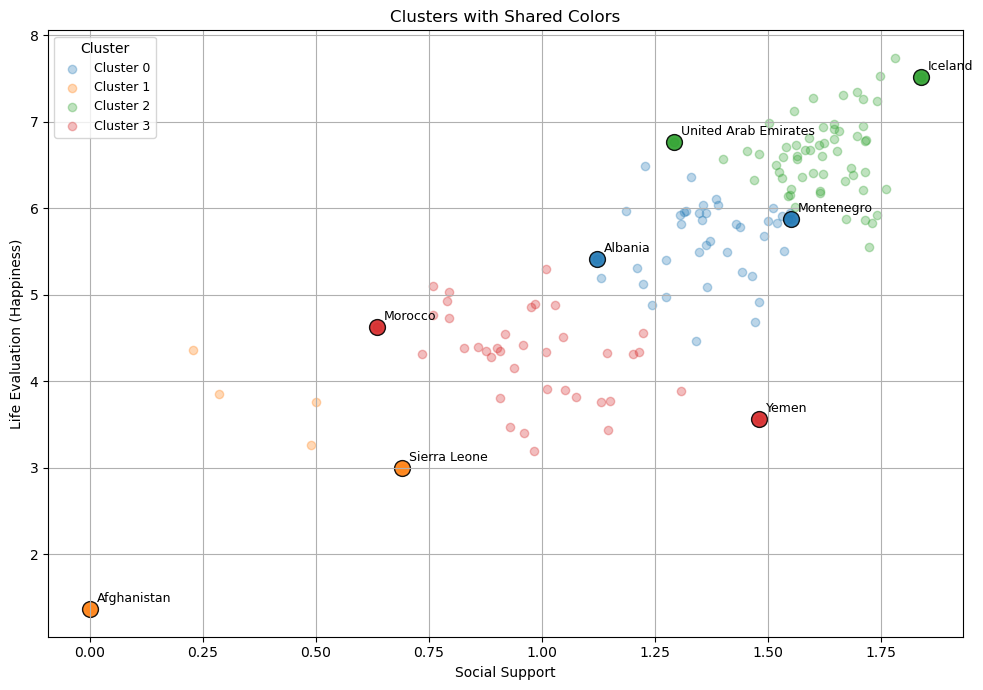

In [34]:
# LOWESS eğrisi

plt.figure(figsize=(10, 7))

# Küme sayısına göre renk paleti
clusters = sorted(df["SocialSupport_Cluster"].unique())
palette = sns.color_palette("tab10", len(clusters))

# Tüm ülkeler ve uç değerler aynı küme rengi ile
for cluster, color in zip(clusters, palette):
    subset = df[df["SocialSupport_Cluster"] == cluster]
    
    # Tüm ülkeler
    plt.scatter(
        subset["Social_support"],
        subset["Life_evaluation_3_year_average"],
        color=color,
        alpha=0.3,
        label=f"Cluster {cluster}"
    )
    
    # Küme içi min & max Social_support (aynı renkte, kenarlıkla vurgulu)
    cluster_extremes = subset.loc[
        subset["Social_support"].isin([subset["Social_support"].min(), subset["Social_support"].max()])
    ]
    plt.scatter(
        cluster_extremes["Social_support"],
        cluster_extremes["Life_evaluation_3_year_average"],
        color=color,
        edgecolor="black",
        s=130,
        alpha=0.9
    )
    
    # Uç değerlerin isimlerini yazdır
    for _, row in cluster_extremes.iterrows():
        plt.annotate(
            row["Country_name"],
            (row["Social_support"], row["Life_evaluation_3_year_average"]),
            textcoords="offset points",
            xytext=(5,5),
            fontsize=9
        )



plt.xlabel("Social Support")
plt.ylabel("Life Evaluation (Happiness)")
plt.title("Clusters with Shared Colors")
plt.legend(title="Cluster", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()


Doğrusal Olmayan İlişki: İlk grafikteki LOWESS eğrisi, sosyal destek arttıkça mutluluğun doğrusal (lineer) değil, ivmelenerek arttığını gösteriyor. Bu durum, XGBoost gibi ağaç tabanlı modellerin bu karmaşık ilişkiyi yakalamada neden daha başarılı olabileceğini açıklar.

Yemen Örneği: Yemen'in konumu, mutluluğu etkileyen tek faktörün sosyal destek olmadığını (muhtemelen çatışma veya ekonomik kriz gibi dışsal faktörlerin etkili olduğunu) gösteriyor.

Kümeleme Başarısı: Ülkelerin birbirine yakınlığı ve renklerin net ayrımı, kümeleme işleminin oldukça başarılı çalıştığını kanıtlıyor.

In [35]:
# Sosyal Destek ile Yaşam Değerlendirmesi arasındaki ilişkinin şiddeti (eğimi)

slopes = []

for cluster in df["SocialSupport_Cluster"].unique():
    subset = df[df["SocialSupport_Cluster"] == cluster]
    X = subset[["Social_support"]].values
    y = subset["Life_evaluation_3_year_average"].values
    model = LinearRegression().fit(X, y)
    slopes.append({"Cluster": cluster, "Slope": model.coef_[0]})

slopes_df = pd.DataFrame(slopes).sort_values("Slope", ascending=False)
print(slopes_df)


   Cluster     Slope
0        1  1.593646
2        2  0.672197
1        0  0.513348
3        3 -1.287605


<Figure size 1000x700 with 0 Axes>

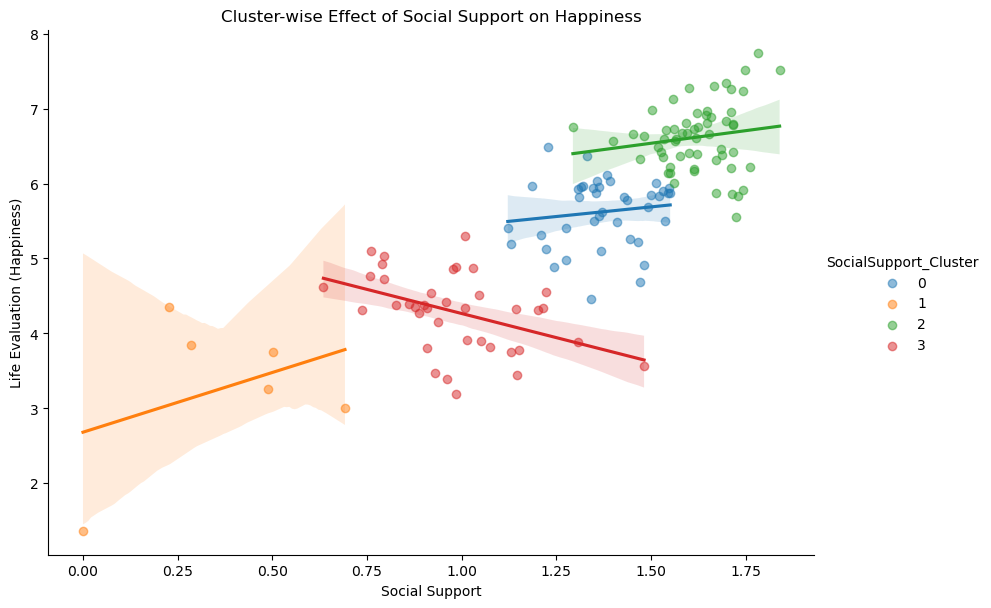

In [36]:


plt.figure(figsize=(10,7))
sns.lmplot(
    data=df,
    x="Social_support",
    y="Life_evaluation_3_year_average",
    hue="SocialSupport_Cluster",
    palette="tab10",
    height=6,
    aspect=1.4,
    markers="o",
    scatter_kws={"alpha":0.5}
)

plt.title("Cluster-wise Effect of Social Support on Happiness")
plt.xlabel("Social Support")
plt.ylabel("Life Evaluation (Happiness)")
plt.show()


Bu grafik, her küme için ayrı ayrı çizilen doğrusal regresyon çizgileriyle (slope), sosyal desteğin mutluluk üzerindeki etkisinin her grupta aynı olmadığını, hatta bazı gruplarda şaşırtıcı sonuçlar verdiğini gösteriyor.

Grafik Üzerinden Küme Analizi ve Eğimlerin Yorumu:

Cluster 1 (Turuncu) & Cluster 0 (Mavi) & Cluster 2 (Yeşil): Bu üç kümede de regresyon çizgisi yukarı yönlü. Yani sosyal destek arttıkça mutluluk da artıyor. Beklenen ve teoriyi destekleyen sonuç budur.

Cluster 3 (Kırmızı) - Büyük Paradoks: Kırmızı hattın eğimi negatif görünüyor. Bu gruptaki ülkelerde (Fas ve Yemen gibi) sosyal destek puanı artsa bile yaşam değerlendirmesi puanının düştüğü veya çok istikrarsız olduğu görülüyor.

Neden Bazı Kümelerde Eğim Negatif?

Aykırı Değer Etkisi: Özellikle Yemen, yüksek bir sosyal destek algısına  sahip olmasına rağmen çok düşük bir mutluluk puanına sahip. Bu tek bir nokta, tüm kırmızı çizginin eğimini aşağı çekiyor olabilir.

Gizli Değişkenler: Bu kümedeki ülkelerde mutluluğu belirleyen ana unsur sosyal destekten ziyade; ekonomik kriz, güvenlik veya özgürlükler gibi sosyal desteğin etkisini "maskeleyen" diğer faktörler olabilir.

In [37]:
#!pip install geopandas


In [38]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


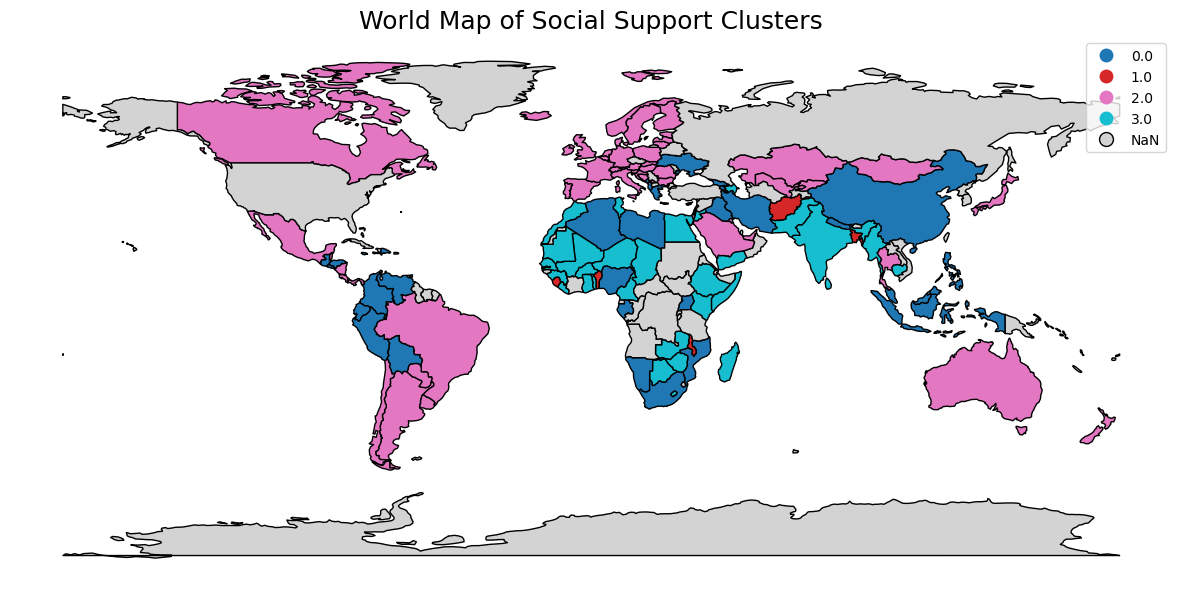

In [39]:

# 1️⃣ Dünya haritasını GeoJSON üzerinden yükle
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(url)

# 2️⃣ Ülke isimlerini df ile eşleştir (merge)
world_df = world.merge(
    df[['Country_name', 'SocialSupport_Cluster']],
    how='left',
    left_on='name',
    right_on='Country_name'
)

# 3️⃣ Küme sayısına göre renk paleti
import matplotlib.cm as cm

n_clusters = df["SocialSupport_Cluster"].nunique()
colors = cm.tab10(range(n_clusters))

# 4️⃣ Harita çizimi
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

world_df.plot(
    column='SocialSupport_Cluster',
    categorical=True,
    cmap='tab10',
    legend=True,
    missing_kwds={'color': 'lightgrey'},
    edgecolor='black',
    ax=ax
)

ax.set_title("World Map of Social Support Clusters", fontsize=18)
ax.set_axis_off()
plt.show()


Dünya Haritası ve Kümeleme Analizi

Harita üzerindeki renk dağılımı, sosyal desteğin coğrafi bölgelere göre nasıl kümelendiğini çok net bir şekilde özetliyor:

Cluster 2.0 (Pembe - Refah): Kuzey Amerika, Avrupa'nın büyük bir kısmı, Avustralya ve İskandinav ülkeleri bu grupta. Daha önceki grafiklerde "Zirve Grup" olarak tanımladığımız bu bölgeler, sosyal desteğin en yüksek olduğu yerler.

Cluster 0.0 (Lacivert - Üst-Orta): Güney Amerika, Rusya, Çin ve Brezilya gibi ülkeler bu grupta yer alıyor. Gelişmekte olan ancak sosyal güvenlik ağları nispeten güçlü bölgeler.

Cluster 3.0 (Turkuaz - Alt-Orta): Afrika'nın büyük bir kısmı ve Güney Asya (Hindistan çevresi) bu kümede. Hatırlarsanız bu küme, sosyal desteğe rağmen mutluluğun bazen düştüğü (negatif eğim - Yemen örneği) "paradoksal" gruptu.

Cluster 1.0 (Kırmızı - Risk): Haritada çok küçük noktalar (Afganistan gibi) olarak görülen bu ülkeler, sosyal desteğin ve mutluluğun en düşük olduğu kritik bölgeleri temsil ediyor.

--> Harita üzerinde NaN olarak gözüken çoğu ülke yüksek ihtimalle veriseti ve ülke adlarının uyuşmamasından kaynaklıdır. Örn: Türkiye -> Turkey